This notebook assume one has activated the conda environment: `Summer2026-py311` (in the workstation).

# Opening and accessing the file

In [1]:
from pathlib import Path
# Replace this with your own path to the `SURIP2026` directory
GIT_REPO_PATH = Path.cwd().parent

import sys
sys.path.append(GIT_REPO_PATH.as_posix())
from utils import h5load

main_dir = Path("/users/shared.user/Summer2026/cogwheel_O4_gaussian_injections/PE/IntrinsicLVCPrior/")

unlensed = main_dir / "unlensed_samples/processed_samples"
images_2 = main_dir / "2_images_samples/processed_samples"
images_3 = main_dir / "3_images_samples/processed_samples"
images_4 = main_dir / "4_images_samples/processed_samples"

all_unlensed = list(unlensed.glob("*.h5"))
all_images_2 = list(images_2.glob("*.h5"))
all_images_3 = list(images_3.glob("*.h5"))
all_images_4 = list(images_4.glob("*.h5"))

In [2]:
# Show the available files in each directory
print(f"Unlensed samples: {len(all_unlensed)}")
print(f"2-images samples: {len(all_images_2)}")
print(f"3-images samples: {len(all_images_3)}")
print(f"4-images samples: {len(all_images_4)}")

Unlensed samples: 1486
2-images samples: 9925
3-images samples: 2974
4-images samples: 3978


In [4]:
# Try access the first file in the 2-images samples
target_file = all_images_2[0]
print(f"The filename is: {target_file.name}")

df = h5load(target_file)
print(f"The event name is {df.attrs['event_name']}")
print(f"The number of posterior samples is {len(df)}")

The filename is: MD_SDSS_l2_1001_1_bilby_style_samples.h5
The event name is MD_SDSS_l2_1001_1
The number of posterior samples is 13339


# Plotting

In [7]:
## Check the injection parameters
inj_dict = df.attrs['injection_values']
print(list(inj_dict.keys()))
print(list(df.columns))

['iota', 'ra', 'dec', 'psi', 't_geocenter', 'SNR_net', 'mass_1', 'mass_2', 'luminosity_distance', 'reference_frequency', 'spin_1z', 'spin_2z', 'lambda_1', 'lambda_2', 'total_mass', 'chirp_mass', 'mass_ratio', 'redshift', 'mass_1_source', 'mass_2_source', 'chirp_mass_source', 'total_mass_source', 'spin_1x', 'spin_1y', 'spin_2x', 'spin_2y', 'phase', 'chi_eff', 'chi_p']
['mass_1', 'mass_2', 'spin_1z', 'spin_2z', 'iota', 'luminosity_distance', 'ra', 'dec', 'phase', 'psi', 'geocent_time', 'lnlike', 'spin_1x', 'spin_1y', 'spin_2x', 'spin_2y', 'theta_jn', 'a_1', 'a_2', 'tilt_1', 'tilt_2', 'phi_12', 'phi_jl', 'mass_ratio', 'chirp_mass', 'cos_theta_jn', 'sin_dec', 'chi_eff', 'chi_1_in_plane', 'chi_2_in_plane', 'chi_p', 'network_optimal_snr', 'log_likelihood', 'total_mass', 'redshift', 'mass_1_source', 'mass_2_source', 'chirp_mass_source', 'total_mass_source']


Text(0, 0.5, '$p(\\chi_{\\rm eff}|d)$')

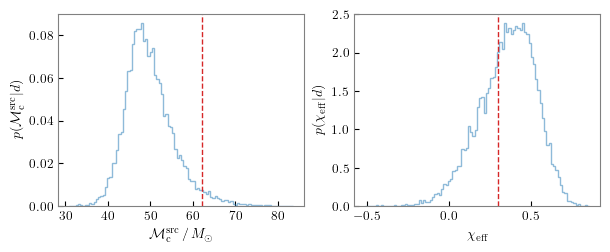

In [12]:
import matplotlib.pyplot as plt

hist_kwargs = {"bins": 100, "density": True, "alpha": 0.5, "histtype": "step"}
fig, axes = plt.subplots(1, 2, figsize=(7, 2.5))
ax = axes[0]
ax.hist(df["chirp_mass_source"], **hist_kwargs)
ax.axvline(inj_dict['chirp_mass_source'], color="C3", linestyle="--")
ax.set_xlabel(r"${\cal M}_{\rm c}^{\rm src}\,/\,M_\odot$")
ax.set_ylabel(r"$p({\cal M}_{\rm c}^{\rm src}|d)$")
ax = axes[1]
ax.hist(df["chi_eff"], **hist_kwargs)
ax.axvline(inj_dict['chi_eff'], color="C3", linestyle="--")
ax.set_xlabel(r"$\chi_{\rm eff}$")
ax.set_ylabel(r"$p(\chi_{\rm eff}|d)$")

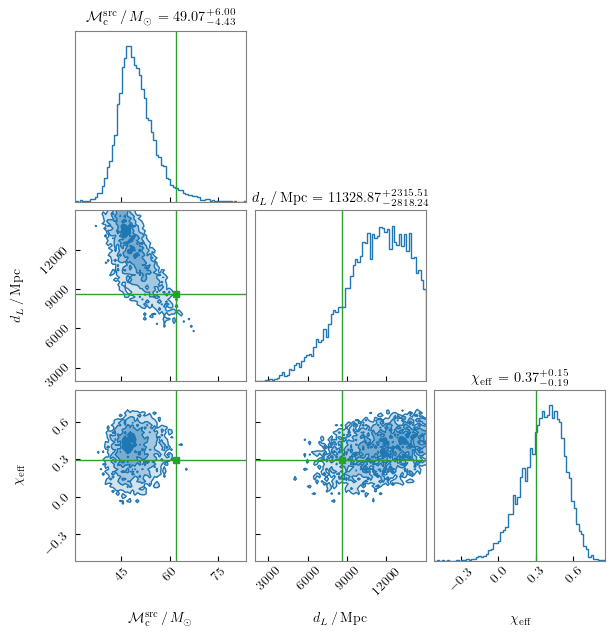

In [ ]:
## Show the correlation between mass, distance and chi_eff
from corner import corner

fig = plt.figure(figsize=(6.5, 6.5))

fig = corner(df[["chirp_mass_source", "luminosity_distance", "chi_eff"]], 
       bins=70, plot_datapoints=False, fill_contours=True,
       show_titles=True, color="C0", truth_color="C2", fig=fig,
       labels=[r"${\cal M}_{\rm c}^{\rm src}\,/\,M_\odot$", r"$d_L\,/\,{\rm Mpc}$", r"$\chi_{\rm eff}$"],
       truths=[inj_dict['chirp_mass_source'], inj_dict['luminosity_distance'], inj_dict['chi_eff']])

# Loading with FIGARO

In [ ]:
from data_processing import load_data

# Check the options of the `load_data` function
load_data?

Signature:
load_data(
    dir_path,
    seed=False,
    par=None,
    n_samples=-1,
    cosmology='Planck18',
    volume=False,
    waveform='combined',
    snr_threshold=None,
    far_threshold=None,
    verbose=True,
    likelihood=False,
    keep_dVdz=False,
    blacklist_events=None,
)
Docstring:
Loads the data .h5/.hdf5 files (processed cogwheel posterior files).
Default cosmological parameters from Planck Collaboration (2021) in a flat Universe (https://www.aanda.org/articles/aa/pdf/2020/09/aa33910-18.pdf)
Not all GW parameters are implemented: run figaro.load.available_gw_pars() for a list of available parameters.

Arguments:
    str or Path path:       folder with data files
    bool seed:              fixes the seed to a default value (1) for reproducibility
    list-of-str par:        list with parameter(s) to extract from GW posteriors
    int n_samples:          number of samples for (random) downsampling. Default -1: all samples
    str cosmology:          set of cosmologi

In [12]:
# This will take some time to run
loaded_data, event_names = load_data(
    dir_path=images_2,
    seed=False,
    par=['m1', 'm2'],
    n_samples=-1,
)

print(event_names)
print("Total loaded events:", len(event_names))

Loading events: 100%|██████████| 9925/9925 [05:40<00:00, 29.13it/s]

['MD_SDSS_l2_1001_1' 'MD_SDSS_l2_1002_1' 'MD_SDSS_l2_1003_1' ...
 'MD_SDSS_l2_997_1' 'MD_SDSS_l2_999_1' 'MD_SDSS_l2_9_0']
Total loaded events: 9925


In [ ]:
# However, there are events that do not have the all the images
# We exclude them in this example
event_status = np.load(main_dir / "event_preprocessing_status.npy")
bad_event_names = event_status['event_name'][event_status['status'] != 0]
# print(list(bad_event_names))

# This will take some time to run
loaded_data, event_names = load_data(
    dir_path=images_2,
    seed=False,
    par=['m1', 'm2'],
    n_samples=-1,
    likelihood=True,
    blacklist_events=bad_event_names.tolist()
)

print("Note the different total loaded events:", len(event_names))

File MD_SDSS_l2_1090_1_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_1464_1_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_1910_1_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_230_0_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_2412_0_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_3506_0_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_3744_1_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_3931_1_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_3969_1_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_4241_0_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_4378_1_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_460_0_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_4683_1_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_617_1_bilby_style_samples.h5 is blacklisted, skipp

Loading events: 100%|██████████| 9909/9909 [05:10<00:00, 31.96it/s]


Note the different total loaded events: 9909


## Check injection values

In [2]:
import pandas as pd

fig_dir = GIT_REPO_PATH / "figures" 
fig_dir.mkdir(exist_ok=True)

inj_unlensed = main_dir.parent / "O4_MD_SDSS_unlensed_inj_params.csv"
inj_pair_0 = main_dir.parent / "O4_MD_SDSS_lensed_pairs_inj_params_0.csv"
inj_triplet_0 = main_dir.parent / "O4_MD_SDSS_lensed_triplets_inj_params_0.csv"
inj_quad_0 = main_dir.parent / "O4_MD_SDSS_lensed_quads_inj_params_0.csv"

inj_unlensed_df = pd.read_csv(inj_unlensed)
inj_pair = inj_pair_0_df = pd.read_csv(inj_pair_0)
inj_triplet = inj_triplet_0_df = pd.read_csv(inj_triplet_0)
inj_quad = inj_quad_0_df = pd.read_csv(inj_quad_0)

for idx in (0, 1, 2, 3): 
    try:
        pair_df = pd.read_csv(main_dir.parent / f"O4_MD_SDSS_lensed_pairs_inj_params_{idx}.csv")
        inj_pair = pd.concat([inj_pair, pair_df])
    except FileNotFoundError:
        continue
    try: 
        triplet_df = pd.read_csv(main_dir.parent / f"O4_MD_SDSS_lensed_triplets_inj_params_{idx}.csv")
        inj_triplet = pd.concat([inj_triplet, triplet_df])
    except FileNotFoundError:
        continue
    try:
        quad_df = pd.read_csv(main_dir.parent / f"O4_MD_SDSS_lensed_quads_inj_params_{idx}.csv")
        inj_quad = pd.concat([inj_quad, quad_df])
    except FileNotFoundError:
        continue

from utils import cogwheel_to_bilby

inj_unlensed_df = cogwheel_to_bilby(inj_unlensed_df)
inj_pair_0_df = cogwheel_to_bilby(inj_pair_0_df)
inj_triplet_0_df = cogwheel_to_bilby(inj_triplet_0_df)
inj_quad_0_df = cogwheel_to_bilby(inj_quad_0_df)


In [3]:
inj_pair_0_df.keys()

Index(['Unnamed: 0', 'iota', 'ra', 'dec', 'psi', 'idx', 'event_name',
       'morse_factor', 'duration', 'mass_1', 'mass_2', 'luminosity_distance',
       'reference_frequency', 'spin_1z', 'spin_2z', 'lambda_1', 'lambda_2',
       'network_optimal_snr', 'geocent_time', 'total_mass', 'chirp_mass',
       'mass_ratio', 'redshift', 'mass_1_source', 'mass_2_source',
       'chirp_mass_source', 'total_mass_source', 'spin_1x', 'spin_1y',
       'spin_2x', 'spin_2y', 'phase', 'a_1', 'a_2', 'tilt_1', 'tilt_2',
       'chi_eff', 'chi_p'],
      dtype='object')

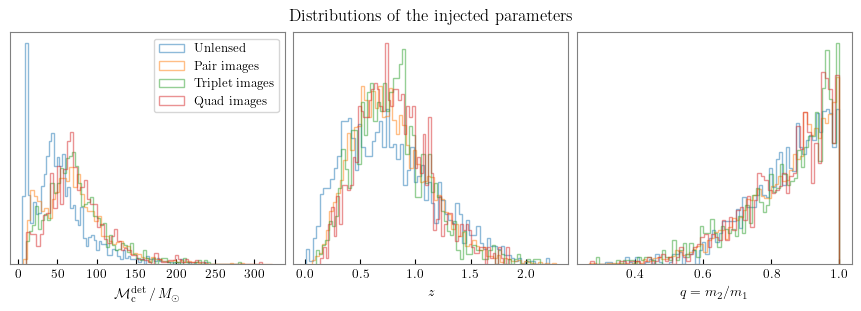

In [43]:
hist_kwargs = {"bins": 70, "density": True, "alpha": 0.5, "histtype": "step"}
fig, axes = plt.subplots(1, 3, figsize=(8.5, 3), constrained_layout=True)
ax = axes[0]
param = 'chirp_mass'
ax.hist(inj_unlensed_df[param], **hist_kwargs, label='Unlensed')
ax.hist(inj_pair_0_df[param], **hist_kwargs, label='Pair images')
ax.hist(inj_triplet_0_df[param], **hist_kwargs, label='Triplet images')
ax.hist(inj_quad_0_df[param], **hist_kwargs, label='Quad images')
ax.set_xlabel(r"${\cal M}_{\rm c}^{\rm det}\,/\,M_\odot$")
ax.legend()
ax = axes[2]
param = 'mass_ratio'
ax.hist(inj_unlensed_df[param], **hist_kwargs)
ax.hist(inj_pair_0_df[param], **hist_kwargs)
ax.hist(inj_triplet_0_df[param], **hist_kwargs)
ax.hist(inj_quad_0_df[param], **hist_kwargs)
ax.set_xlabel(r"$q = m_2 / m_1$")
ax = axes[1]
param = "redshift"
ax.hist(inj_unlensed_df[param], **hist_kwargs)
ax.hist(inj_pair_0_df[param], **hist_kwargs)
ax.hist(inj_triplet_0_df[param], **hist_kwargs)
ax.hist(inj_quad_0_df[param], **hist_kwargs)
ax.set_xlabel(r"$z$")

for ax in axes:
    ax.set_yticks([])

fig.suptitle("Distributions of the injected parameters")
fig.savefig(fig_dir / "injected_parameter_distributions.png")